### Imports

In [1]:
import itertools
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib 
import matplotlib.pyplot as plt
%matplotlib inline

### Reprise du code de 2_1_bradley_terry 

In [2]:
df_votes = pd.read_parquet("../votes.parquet")
df_filtered = df_votes[df_votes["both_equal"] == False]

In [3]:
def get_occurences_model(df:pd.DataFrame) -> pd.Series:
    """Récupère les modèles et leur nombre d'occurrences dans les colonnes `model_a_name` et `model_b_name`."""
    model_names_a = df["model_a_name"].value_counts()
    model_names_b = df["model_b_name"].value_counts()

    # Mise en commun des deux séries
    return model_names_a.add(model_names_b, fill_value=0).sort_values(ascending=False)

def build_ranking(model_names:list[str], df:pd.DataFrame) -> np.ndarray:
    """
    Construit la matrice de gain où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes.
    """
    gains = np.zeros((len(model_names), len(model_names)), dtype=int)
    for row in df.itertuples():
        if row.model_a_name in model_names and row.model_b_name in model_names:
            i = model_names.index(row.model_a_name)
            j = model_names.index(row.model_b_name)
            if i == j:
                continue
            if row.chosen_model_name == row.model_a_name:
                gains[i, j] += 1
            elif row.chosen_model_name == row.model_b_name:
                gains[j, i] += 1
    return gains

def estimate_bradley_terry(W: np.ndarray, tol: float = 1e-8, max_iter: int = 10000):
    """
    Estime les paramètres β du modèle de Bradley-Terry via l'algorithme
    itératif original (Bradley & Terry 1952 / Hunter 2004 MM).

    Args:
        W        : matrice (k, k) — W[i,j] = nb de victoires de i sur j
        tol      : critère d'arrêt sur la variation max de β
        max_iter : garde-fou

    Returns:
        beta     : paramètres estimés (non normalisés)
        ranking  : indices triés par β décroissant
    """
    k = W.shape[0]
    beta = np.ones(k)

    # Wins totaux de chaque modèle — constants, précalculés hors boucle
    W_wins = W.sum(axis=1)          # W_wins[i] = nombre total de victoires de i
    W_total = W + W.T               # W_total[i,j] = duels totaux entre i et j

    for i in range(max_iter):
        beta_old = beta.copy()

        # Mise à jour simultanée de tous les β (forme vectorisée)
        # denom[i] = Σⱼ≠ᵢ  (Wᵢⱼ + Wⱼᵢ) / (βᵢ + βⱼ)
        denom = (W_total / (beta[:, None] + beta[None, :])).sum(axis=1)

        # Éviter division par zéro pour les modèles sans aucune victoire
        beta = np.where(W_wins > 0, W_wins / denom, 1e-10)

        # Normalisation pour fixer l'identifiabilité (sum = k)
        beta /= beta.mean()

        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {i+1} itérations.")
            break

    ranking = np.argsort(beta)[::-1]
    return beta, ranking

## Exercice 2.2

### Transitivité stochastique

On cherche à vérifier la transitivité stochastique du modèle de Bradley-Terry sur le sous-graphe des 20 modèles les plus comparés. Remarquons d'abord qu'il existe plusieurs définitions pour la transitivité stochastique : forte, faible, linéaire, .... Pour les tests suivants, on comparera les résultats avec les deux définitions ci-dessous.

Transitivité stochastique faible (Weak Stochastic Transitivity) :

$P(i \succeq j) \geq 1/2 \land P(j \succeq k) \geq 1/2 \implies P(i \succeq k) \geq 1/2$

Transitivité stochastique forte (Strong Stochastic Transitivity) :

$P(i \succeq j) \geq 1/2 \land P(j \succeq k) \geq 1/2 \implies P(i \succeq k) \geq max(P(i \succeq j), P(j \succeq k))$

On peut également étendre ces défintions à tous seuils de la façon suivante.

Pour la transitivité stochastique faible (Weak Stochastic Transitivity) :

$\forall s \in [0,1], P(i \succeq j) \geq s \land P(j \succeq k) \geq s \implies P(i \succeq k) \geq s$

Pour la transitivité stochastique forte (Strong Stochastic Transitivity) :

$\forall s \in [0,1], P(i \succeq j) \geq s \land P(j \succeq k) \geq s \implies P(i \succeq k) \geq max(P(i \succeq j), P(j \succeq k))$


In [4]:
def test_stochastic_transitivity(beta: np.ndarray, threshold: float = 0.5, type = "weak") -> dict:
    """
    Teste la transitivité stochastique (Weak Stochastic Transitivity) sur le threshold à partir des paramètres beta du modèle de Bradley-Terry.

    Args:
        beta (np.ndarray): paramètres estimés de Bradley-Terry
        threshold (float): seuil de décision (0.5 par défaut)
        type (string): "weak" ou "strong", le type de transitivité utilisé ("weak" par défaut)

    Returns:
        dict: métriques de transitivité
    """

    n = len(beta)

    total_triplets = 0
    transitive = 0
    violations = 0

    # Probabilité de Bradley-Terry
    def p(i, j):
        return beta[i] / (beta[i] + beta[j])

    for i, j, k in itertools.permutations(range(n), 3):

        pij = p(i, j)
        pjk = p(j, k)
        pik = p(i, k)

        if type == "weak":
            goal = threshold
        elif type == "strong":
            goal = max(pij, pjk)
        else:
            raise(ValueError(f"'{type}' is not a valid type of stochastic transitivity, choose wether 'weak' or 'strong'."))

        # Condition de transitivité stochastique
        if pij > threshold and pjk > threshold:
            total_triplets += 1

            if pik > goal:
                transitive += 1
            else:
                violations += 1

    return {
        "total_triplets": total_triplets,
        "transitive": transitive,
        "violations": violations,
        "transitivity_rate": transitive / total_triplets if total_triplets > 0 else np.nan
    }

Testons la transitivité stochastique faible du modèle de Bradley-Terry :

In [5]:
# Top 20 des modèles les plus comparés
model_names = get_occurences_model(df_filtered)
top_20_models = model_names.head(20).index.tolist()

# Coefficients de Bradley-Terry
W = build_ranking(top_20_models, df_filtered)
beta, ranking = estimate_bradley_terry(W)

# Test de transitivité (faible)
for i in range(10):
    results = test_stochastic_transitivity(beta, i*0.1, type="weak")
    print(f"Seuil : {i/10}, results : {results}")


Convergence atteinte après 70 itérations.
Seuil : 0.0, results : {'total_triplets': 6840, 'transitive': 6840, 'violations': 0, 'transitivity_rate': 1.0}
Seuil : 0.1, results : {'total_triplets': 6840, 'transitive': 6840, 'violations': 0, 'transitivity_rate': 1.0}
Seuil : 0.2, results : {'total_triplets': 6552, 'transitive': 6438, 'violations': 114, 'transitivity_rate': 0.9826007326007326}
Seuil : 0.3, results : {'total_triplets': 5076, 'transitive': 4750, 'violations': 326, 'transitivity_rate': 0.9357762017336485}
Seuil : 0.4, results : {'total_triplets': 2886, 'transitive': 2742, 'violations': 144, 'transitivity_rate': 0.9501039501039501}
Seuil : 0.5, results : {'total_triplets': 1140, 'transitive': 1140, 'violations': 0, 'transitivity_rate': 1.0}
Seuil : 0.6, results : {'total_triplets': 186, 'transitive': 186, 'violations': 0, 'transitivity_rate': 1.0}
Seuil : 0.7, results : {'total_triplets': 0, 'transitive': 0, 'violations': 0, 'transitivity_rate': nan}
Seuil : 0.8, results : {'to

Globalement, pour tous les seuils testés, les taux de transitivité (faible) sont très élevés, avec un minimum à 93% : le modèle de Bradley-Terry tend donc à respecter la transitivité stochastique faible sur tous les seuils, voir à la respecter complétement sur le seuil à 0.5, qui est celui retenu usuellement pour la définition de la transitivité stochastique.

On peut également tester les résultats pour la transitivité stochastique forte (Strong Stochastic Transitivity) :

In [6]:
# Top 20 des modèles les plus comparés
model_names = get_occurences_model(df_filtered)
top_20_models = model_names.head(20).index.tolist()

# Coefficients de Bradley-Terry
W = build_ranking(top_20_models, df_filtered)
beta, ranking = estimate_bradley_terry(W)

# Test de transitivité (forte)
for i in range(10):
    results = test_stochastic_transitivity(beta, i*0.1, type="strong")
    print(f"Seuil : {i/10}, results : {results}")

Convergence atteinte après 70 itérations.
Seuil : 0.0, results : {'total_triplets': 6840, 'transitive': 1140, 'violations': 5700, 'transitivity_rate': 0.16666666666666666}
Seuil : 0.1, results : {'total_triplets': 6840, 'transitive': 1140, 'violations': 5700, 'transitivity_rate': 0.16666666666666666}
Seuil : 0.2, results : {'total_triplets': 6552, 'transitive': 1140, 'violations': 5412, 'transitivity_rate': 0.17399267399267399}
Seuil : 0.3, results : {'total_triplets': 5076, 'transitive': 1140, 'violations': 3936, 'transitivity_rate': 0.22458628841607564}
Seuil : 0.4, results : {'total_triplets': 2886, 'transitive': 1140, 'violations': 1746, 'transitivity_rate': 0.39501039501039503}
Seuil : 0.5, results : {'total_triplets': 1140, 'transitive': 1140, 'violations': 0, 'transitivity_rate': 1.0}
Seuil : 0.6, results : {'total_triplets': 186, 'transitive': 186, 'violations': 0, 'transitivity_rate': 1.0}
Seuil : 0.7, results : {'total_triplets': 0, 'transitive': 0, 'violations': 0, 'transiti

Cette fois-ci, les résultats pour les seuils plus petits sont beaucoup plus nuancés, et sont croissants en fonction de la valeur du seuil. En revanche, si l'on ne s'intéresse qu'à la définition stricte de transitivité stochastique forte, faisant intervenir un seuil de 0.5, on peut dire que le modèle de Bradley-Terry, sur les 20 modèles les plus comparés, est fortement transitif.

### Test de puissance pour distinction statistique

In [7]:
def required_comparisons(p, alpha=0.05, power=0.8):
    """
    Calcule le nombre de comparaisons nécessaires pour détecter p > 0.5 avec un test binomial
    """
    z_alpha = norm.ppf(1 - alpha / 2)
    z_power = norm.ppf(power)

    numerator = (z_alpha + z_power) ** 2 * p * (1 - p)
    denominator = (p - 0.5) ** 2

    n = numerator / denominator
    return int(np.ceil(n))

In [8]:
# Probabilité de Bradley-Terry
p = beta[2] / (beta[2] + beta[4])

# Nombre de comparaisons minimum requises
n_required = required_comparisons(p)

print(f"p = {p}")
print(f"Nombre minimum de comparaisons : {n_required}")

p = 0.31285617051206016
Nombre minimum de comparaisons : 49


Il faut un très grand nombre de comparaisons pour pouvoir distinguer statistiquement le modèle 3 du modèle 5 !

### Extension de Davidson

Pour pouvoir prendre en compte les votes ex-aequo entre deux modèles dans le modèle de Bradley-Terry, on peut implémenter l'extension de Davidson.

In [9]:
def build_ranking_davidson(model_names, df):
    """
    Construit les matrices W et T, où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes,
    et T[i, j] est le nombre de fois que le modèle i a été égal au modèle j dans les votes.
    """
    n = len(model_names)

    W = np.zeros((n, n), dtype=int)
    T = np.zeros((n, n), dtype=int)

    for row in df.itertuples():
        if row.model_a_name in model_names and row.model_b_name in model_names:
            i = model_names.index(row.model_a_name)
            j = model_names.index(row.model_b_name)

            if i == j:
                continue

            if row.both_equal:
                T[i, j] += 1
                T[j, i] += 1
            else:
                if row.chosen_model_name == row.model_a_name:
                    W[i, j] += 1
                elif row.chosen_model_name == row.model_b_name:
                    W[j, i] += 1

    return W, T

def estimate_davidson(W, T):
    """
    Estime les paramètres beta et nu du modèle de Bradley-Terry avec extension de Davidson à partir des matrices W et T.

    Args:
        W (np.ndarray): Matrice de gains, W[i,j] = nombre de fois que i bat j.
        T (np.ndarray): Matrice de gains, T[i,j] = nombre de fois que i est j sont égaux.

    Returns:
        np.ndarray: Paramètres beta estimés pour chaque modèle.
        float: Paramètre nu.
        np.ndarray: Classement des modèles (indices des modèles par ordre décroissant de beta).
    """

    n = W.shape[0]

    # Initialisation de beta et nu 
    x0 = np.ones(n + 1)
    x0[-1] = 0.5

    def neg_log_likelihood(x):
        beta = x[:n]
        nu = x[-1]

        if np.any(beta <= 0) or nu <= 0:
            return np.inf

        likelihood = 0.0

        for i in range(n):
            for j in range(i + 1, n):

                wij = W[i, j]
                wji = W[j, i]
                tij = T[i, j]

                if wij + wji + tij == 0:
                    continue

                denom = beta[i] + beta[j] + nu * np.sqrt(beta[i] * beta[j])

                if wij > 0:
                    likelihood += wij * np.log(beta[i] / denom)
                if wji > 0:
                    likelihood += wji * np.log(beta[j] / denom)
                if tij > 0:
                    likelihood += tij * np.log(nu * np.sqrt(beta[i] * beta[j]) / denom)

        return -likelihood # On minimise l'opposé de la log-vraisemblance

    result = minimize(neg_log_likelihood, x0, method='L-BFGS-B')

    beta = result.x[:n]
    nu = result.x[-1]

    ranking = np.argsort(beta)[::-1]

    return beta, nu, ranking

In [10]:
model_names = get_occurences_model(df_votes)
top_20_models = model_names.head(20).index.tolist()

# Coefficients de Bradley-Terry simple
W_bradley = build_ranking(top_20_models, df_votes)
beta_bradley, ranking_bradley = estimate_bradley_terry(W_bradley)

# Coefficients de Bradley-Terry avec extension de Davidson
W_davidson, T_davidson = build_ranking_davidson(top_20_models, df_votes)
beta_davidson, nu_davidson, ranking_davidson = estimate_davidson(W_davidson, T_davidson)

for i in range(len(beta_bradley)):
    print(f"Beta Bradley-Terry : {beta_bradley[i]}; Beta Davidson {beta_davidson[i]}; différence : {beta_bradley[i]-beta_davidson[i]}")
print(f"Nu Davidson : {nu_davidson}")

print("\n")
print(f"Classement par Bradley-Terry : {ranking_bradley}")
print(f"Classement par Davidson : {ranking_davidson}")

Convergence atteinte après 71 itérations.
Beta Bradley-Terry : 0.5170711831801852; Beta Davidson 0.8107920076634317; différence : -0.29372082448324655
Beta Bradley-Terry : 0.4534605523336153; Beta Davidson 0.7143780134343046; différence : -0.2609174611006893
Beta Bradley-Terry : 0.7628478897216767; Beta Davidson 0.9223605360851479; différence : -0.15951264636347118
Beta Bradley-Terry : 1.191042859598697; Beta Davidson 1.0974359368442677; différence : 0.09360692275442939
Beta Bradley-Terry : 0.6514167613309808; Beta Davidson 0.886782605991154; différence : -0.23536584466017318
Beta Bradley-Terry : 0.5634008839339039; Beta Davidson 0.8462595173213427; différence : -0.2828586333874389
Beta Bradley-Terry : 1.7798856161522543; Beta Davidson 1.2408186617048544; différence : 0.5390669544473998
Beta Bradley-Terry : 1.3923236951857776; Beta Davidson 1.149557044083446; différence : 0.24276665110233164
Beta Bradley-Terry : 0.9787041471760913; Beta Davidson 1.0890117890154871; différence : -0.1103

C:\Users\MickaelMartinelliCS\AppData\Roaming\Python\Python313\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


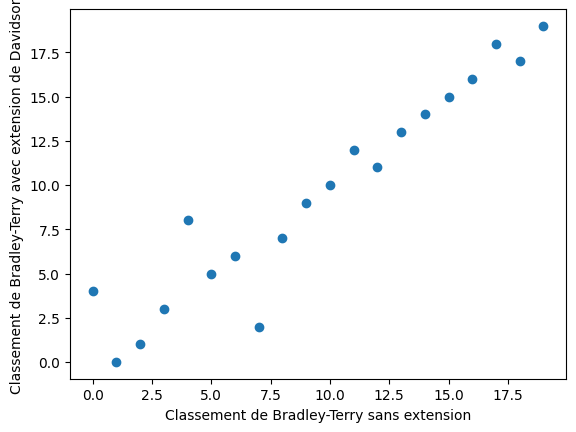

In [ ]:
rank_bt = np.argsort(ranking_bradley)
rank_dv = np.argsort(ranking_davidson)
plt.xlabel("Classement de Bradley-Terry sans extension")
plt.ylabel("Classement de Bradley-Terry avec extension de Davidson")
plt.plot(rank_bt, rank_dv, linestyle='', marker="o")

On observe globalement des scores $\beta$ du même ordre de grandeur, mais avec des différences atteignant souvent plus de 50% de leur valeur. Cela a pour conséquences de produire des modifications locales dans les classements. On peut ainsi conclure que le modèle de Bradley-Terry a une robustesse relative aux ex-aequo : sans prise en compte des cas d'égalité, il produit un classement globalement proche du classement avec extension de Davidson, mais avec quelques disparités locales. Cependant, on remarque aussi un autre phénomène : pour les plus grandes valeurs de $\beta$, la différence de valeurs se creuse entre le modèle standard et l'extension de Davidson. La prise en compte des égalités nuance donc plus fortement les modèles à haute estimation de force créative, c'est-à-dire ceux qui font le plus conscensus. 